# An attempt to construct a variational autoencoder(based on Troels´ autoencoder example)

In [1]:
import os
import random
import itertools

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights

from torch.utils.data import Dataset, DataLoader, random_split

from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn import preprocessing, cluster, manifold
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.datasets import fetch_openml

import umap
from tqdm import tqdm

### Data loading

In [2]:
#Getting the images:
unique_path = r"../data\grand_scraper_folder\unique_scrandle_cases_FULL.csv"
unique_dataframe = pd.read_csv(unique_path)
unique_entries = [unique_dataframe["occurrences"][i].split("|")[0].split(" ")[0] + ".webp" for i in range(len(unique_dataframe["occurrences"]))]

#Next, we´ll get the low-res photos imported(doesnt take long. for my computer: 7.5s)

#Creating a list for the photos with the corresponding dates and image names as well(crude way of being able to see which are outliers.
#Needs to be done better, really. If someone has the time, feel free to find a better way of doing things)
image_Data_low_res = []




#Folder with folders of images:
base_folder = r"../data\scran_sized_low_res_data" #niew pictures.

current_folder = None


#Looping over all dates in the listed directory/folder:
for entry in sorted(unique_entries):
    date, image_placement = entry.split(":")
    
    #Finding a new date folder to check
    date_path = os.path.join(base_folder, date)
    #Checking if the date path exists
    if not os.path.isdir(date_path):
        continue

    print(f"Processing {entry}")
    
    #Reading entry image:
    image_path = os.path.join(date_path, image_placement)
    image_Data_low_res.append({
                    "date": date,
                    "image_name": image_placement,
                    "RGB": plt.imread(image_path, format="webp"),
                })

Processing 2025-04-20:0_left.webp
Processing 2025-04-20:0_right.webp
Processing 2025-04-20:1_left.webp
Processing 2025-04-20:1_right.webp
Processing 2025-04-20:2_left.webp
Processing 2025-04-20:2_right.webp
Processing 2025-04-20:3_left.webp
Processing 2025-04-20:3_right.webp
Processing 2025-04-20:4_left.webp
Processing 2025-04-20:4_right.webp
Processing 2025-04-20:5_left.webp
Processing 2025-04-20:5_right.webp
Processing 2025-04-20:6_left.webp
Processing 2025-04-20:6_right.webp
Processing 2025-04-20:7_left.webp
Processing 2025-04-20:7_right.webp
Processing 2025-04-20:8_left.webp
Processing 2025-04-20:8_right.webp
Processing 2025-04-20:9_left.webp
Processing 2025-04-20:9_right.webp
Processing 2025-04-21:0_left.webp
Processing 2025-04-21:0_right.webp
Processing 2025-04-21:1_left.webp
Processing 2025-04-21:1_right.webp
Processing 2025-04-21:2_left.webp
Processing 2025-04-21:2_right.webp
Processing 2025-04-21:3_left.webp
Processing 2025-04-21:3_right.webp
Processing 2025-04-21:4_left.webp


In [32]:
#Getting only the images:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using Device: {device}")
image_only_low_res = []
for i in range(len(image_Data_low_res)):
    image_only_low_res.append(image_Data_low_res[i]["RGB"])
image_scran_torch_pre = torch.from_numpy(np.array(image_only_low_res[:])/255).permute(0,3,1,2).float().to(device)


Using Device: cuda


In [187]:
#Batch size and latent dim:
d = 145
batch_size = 96

In [188]:
#Next, for the dataloader:
class ImageDataset(Dataset):
    def __init__(self, images):
        
        self.images = images

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        return image
image_scran_torch = ImageDataset(image_scran_torch_pre)
train_size = int(0.8 * len(image_scran_torch))
test_size = len(image_scran_torch) - train_size
train_dataset, test_dataset = random_split(image_scran_torch, [train_size, test_size], generator=torch.Generator().manual_seed(42))

loader_train = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
loader_test = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [189]:
# LOSS FUNCTION

loss_fn = nn.L1Loss()

### Model(Adapted from Troels autoencoder example solution)

### Now to try to get ResNet to work:

In [199]:
class RN_encoder(nn.Module): #Same for new resolution.
    """
    The Encoder for ResNet50. Uses pretrained ResNet50 with weights.
    """

    def __init__(self, encoded_space_dim):
        super().__init__()

        # Load pretrained ResNet50 
        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)

        # Remove final fully connected layer going to  keep feature extractor
        # Output shape: (B, 2048, 1, 1)
        self.feature_extractor = nn.Sequential(
            *list(resnet.children())[:-1]
        )

        # Flatten (B, 2048, 1, 1) going to (B, 2048)
        self.flatten = nn.Flatten() #Flat me baby one more time.

        # Compressing to the latent space.
        self.encoder_lin = nn.Sequential(
            nn.Linear(2048, 128),
            nn.ReLU(True),
            nn.Linear(128, encoded_space_dim)
        )

    def forward(self, x):
        x = self.feature_extractor(x)   # Extract features
        x = self.flatten(x)             # Flatten
        x = self.encoder_lin(x)         # Latent vector
        return x

In [200]:
# RESNET FRON HERE

# Done with respcect to the 100x85 pictures  : ()
class Decoder_RN(nn.Module):
    """
    Decoder that reconstructs images from latent vectors.

    latent →
      FC expansion →
        reshape →
          ConvTranspose
    """

    def __init__(self, encoded_space_dim):
        super().__init__()

        # Expand latent vector → feature map
        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),

            # nn.Linear(128, 256 * 4 * 4), # OLD: produced 32x32 output
            nn.Linear(128, 256 * 6 * 5),   # NEW: start from bigger feature map (~better resolution)
            nn.ReLU(True)
        )

        # Reshape to (channels, height, width)
        self.unflatten = nn.Unflatten(
            dim=1,
            # unflattened_size=(256, 4, 4) # OLD
            unflattened_size=(256, 6, 5)   # NEW: matches updated linear layer
        )

        # Upsampling pipeline
        # Padding of 1 used everywhere.
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 6x5 → 12x10
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 12x10 → 24x20
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 24x20 → 48x40
            nn.ReLU(True)            )
        self.final_layer = nn.ConvTranspose2d(
            32, 3,
            kernel_size=(38, 63),
            stride=1,
            padding=0)

    def forward(self, x):
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)   # now ends at (B, 32, 48, 40)

        x = self.final_layer(x)    # → (B, 3, 85, 102)

        x = torch.sigmoid(x)
        return x


In [201]:



# Choose GPU if Christopher, otherwise CPU at weak Ulle.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize encoder (image → latent vector of dim d)
encoder = RN_encoder(d).to(device)

# Initialize decoder (latent vector → reconstructed image) this is the reverse funnel.
rn_decoder = Decoder_RN(d).to(device)

# Combine parameters from BOTH models
# → optimizer will update both encoder and decoder during training
params_to_optimize = list(encoder.parameters()) + list(rn_decoder.parameters())

# Adam optimizer (standard for deep learning)
optim = torch.optim.Adam(
    params_to_optimize,
    lr=1e-3,          # learning rate (step size) #tune this maybe.
    weight_decay=1e-5 # L2 regularization (should prevent overfitting.)
)

In [202]:
def rn_train_epoch(encoder, decoder, dataloader, loss_fn, optimizer, device):
    # Set both models to training mode (important for BatchNorm, Dropout, etc.)
    encoder.train()
    decoder.train()

    train_loss = [] 

    # Loop over batches from dataloader
    #for image_batch in dataloader:
    for image_batch in tqdm(dataloader, desc="Training", leave=False):

        # Move batch to GPU/CPU (Poor poor Ulle)
        image_batch = image_batch.to(device)

        encoded_data = encoder(image_batch)  # use of Encoder

        decoded_data = decoder(encoded_data)  # use of Decoder
        # Compute reconstruction loss (e.g. MSE between input and output)
        loss = loss_fn(decoded_data, image_batch)

        # Backpropagation step
        optimizer.zero_grad()  # reset gradients
        loss.backward()        # compute gradients
        optimizer.step()       # update weights

        # Store loss value for tracking
        train_loss.append(loss.item())

    # Return average loss from the epoch
    return sum(train_loss) / len(train_loss)

In [203]:
def rn_test_epoch(encoder, decoder, dataloader, loss_fn, device):  # THIS IS LE TESTEER
    # Set models to evaluation mode
    # → disables dropout, uses running stats for BatchNorm
    encoder.eval()
    decoder.eval()

    # No gradients needed → saves memory and is faster
    with torch.no_grad():

        losses = []

        # Loop over validation/test data
        #for image_batch in dataloader:
        for image_batch in tqdm(dataloader, desc="Testing", leave=False):

            # Move data to correct device
            image_batch = image_batch.to(device)

            # Forward pass (same as training, but no gradient tracking here)
            encoded_data = encoder(image_batch)   # image → latent
            decoded_data = decoder(encoded_data)  # latent → reconstruction

            #NO INTERPOLATION

            # Compute reconstruction loss
            loss = loss_fn(decoded_data, image_batch)

            # Store loss
            losses.append(loss.item())

    # Return average loss over dataset
    return sum(losses) / len(losses)

In [ ]:
#For plotting purposes:
diz_loss = {
    'train_loss': [],
    'val_loss': []
} 
lrs = []

In [209]:
#To change learning rate
params_to_optimize = list(encoder.parameters()) + list(rn_decoder.parameters())
lr = 1e-5
# Adam optimizer (standard for deep learning)
optim = torch.optim.Adam(
    params_to_optimize,
    lr=lr,          # learning rate (step size) #tune this maybe.
    weight_decay=1e-5 # L2 regularization (should prevent overfitting.)
)
optim

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 1e-05
)

In [208]:
# Number of full passes through the dataset
num_epochs = 15



# Main training loop
for epoch in range(num_epochs):
    # Run one full training epoch
    # updates model weights
    train_loss = rn_train_epoch(
        encoder,
        rn_decoder,
        loader_train,
        loss_fn,
        optim,
        device
    )

    # Run one full validation epoch
    #NO weight updates, only evaluation. 
    val_loss = rn_test_epoch(
        encoder,
        rn_decoder,
        loader_test,
        loss_fn,
        device
    )

    # Print progress for monitoring training, yesyesyes.
    print(
        f"EPOCH {epoch+1}/{num_epochs} "
        f"\t train {train_loss:.4f} "
        f"\t val {val_loss:.4f}"
    )

    # Store losses for later analysis (e.g. plotting)
    diz_loss['train_loss'].append(train_loss)
    diz_loss['val_loss'].append(val_loss)
    lrs.append(lr)

EPOCH 1/15 	 train 0.1483 	 val 0.1510


EPOCH 2/15 	 train 0.1477 	 val 0.1490


EPOCH 3/15 	 train 0.1470 	 val 0.1485


EPOCH 4/15 	 train 0.1462 	 val 0.1480


EPOCH 5/15 	 train 0.1457 	 val 0.1474


...

EPOCH 7/15 	 train 0.1451 	 val 0.1468


EPOCH 8/15 	 train 0.1444 	 val 0.1470


EPOCH 9/15 	 train 0.1440 	 val 0.1459


EPOCH 10/15 	 train 0.1440 	 val 0.1474


KeyboardInterrupt: 

In [158]:
def check_resnet(image_id, dataset): #THis is le evalueation.
    # Set models to evaluation mode (no dropout / stable BatchNorm)
    encoder.eval()
    rn_decoder.eval()

    # No gradients needed → faster + less memory
    with torch.no_grad():

        # Get single image from dataset
        # Add batch dimension → (1, 3, H, W)
        img = dataset[image_id].unsqueeze(0).to(device)

        # Forward pass:
        # image → encoder → latent → decoder → reconstruction
        reconstructed = rn_decoder(encoder(img))


        # Convert tensors → numpy arrays for plotting
        # Also reshape from (C, H, W) → (H, W, C)
        reconstructed = reconstructed.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        original = img.squeeze(0).cpu().numpy().transpose(1, 2, 0)

    # Return both images for comparison
    return reconstructed, original


(85, 102, 3)
(85, 102, 3)


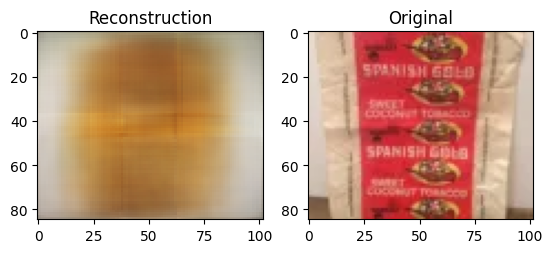

In [186]:
rand_num = np.random.randint(0, len(train_dataset))
recon, orig = check_resnet(rand_num, train_dataset)

plt.subplot(1,2,1)
plt.title("Reconstruction")
plt.imshow(recon, interpolation='nearest')

plt.subplot(1,2,2)
plt.title("Original")
plt.imshow(orig)

print(recon.shape)
print(orig.shape)